In [1]:

import tensorflow as tf
import sys
import os
from typing import List, Tuple, Dict, Union, Optional, Any
import tensorflow_probability as tfp
import sys # For printing warnings/errors

tfb = tfp.bijectors
tfd = tfp.distributions


'''
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    sys.path.insert(1, parent_dir)
'''
sys.path.append('../')

from ConditionalBijectorWrapper import Cond_RealNVP
from RealNVP import *
from Bijectors import *

2025-05-25 11:31:12.511617: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-25 11:31:12.567091: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2025-05-25 11:31:12.567915: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-25 11:31:13.838018: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


# Trainer helper functions


In [2]:
import Trainer


def get_compiler_kwargs(lr: float,
                        ignore_nans: bool,
                        nan_threshold: float
                       ):
    #compiler_kwargs = {'optimizer': {'class_name': 'Adam', # this gives the new Adam optimizer
    compiler_kwargs = {'optimizer': {'class_name': 'Custom>Adam', # this gives the new Adam optimizer
                                     'config': {'learning_rate': lr,
                                                'beta_1': 0.9,
                                                'beta_2': 0.999,
                                                'epsilon': 1e-07,
                                                'amsgrad': True}},
                       'metrics': [{'class_name': 'MinusLogProbMetric',
                                    'config': {'ignore_nans': ignore_nans,
                                               'debug_print_mode': False}}],
                       'loss': {'class_name': 'MinusLogProbLoss',
                                'config': {'name': "MLP",
                                           'ignore_nans': ignore_nans,
                                           'nan_threshold': nan_threshold,
                                           'debug_print_mode': False}}}
    return compiler_kwargs

def get_callbacks_kwargs(#checkpoint_path: str,
                         es_min_delta: float,
                         es_patience: int,
                         lr_reduce_factor: float,
                         lr_min_delta: float,
                         lr_patience: int,
                         min_lr: float
                         ):
    callbacks_kwargs = [{'class_name': 'PrintEpochInfo',
                         'config': {}},
                        #{'class_name': 'HandleNaNCallback',
                        # 'config': {'checkpoint_path': checkpoint_path,
                        #            'lr_reduction_factor': lr_reduce_factor_on_nan,
                        #            'random_seed_var': np.random.randint(1000000)}},
                        #{'class_name': 'TerminateOnNaNFractionCallback',
                        # 'config': {'threshold': 0.1,
                        #            'validation_data': X_data_val}},
                        #{'class_name': 'ModelCheckpoint',
                        # 'config': {#'filepath': checkpoint_path,
                        #            'monitor': 'val_loss',
                        #            'save_best_only': True,
                        #            'save_weights_only': True,
                        #            'verbose': 1,
                        #            'mode': 'auto',
                        #            'save_freq': 'epoch'}},
                        {'class_name': 'EarlyStopping',
                         'config': {'monitor': 'val_loss',
                                    'min_delta': es_min_delta,
                                    'patience': es_patience,
                                    'verbose': 1,
                                    'mode': 'auto',
                                    'baseline': None,
                                    'restore_best_weights': True}},
                        {'class_name': 'ReduceLROnPlateau',
                         'config': {'monitor': 'val_loss',
                                    'factor': lr_reduce_factor,
                                    'min_delta': lr_min_delta,
                                    'patience': lr_patience,
                                    'min_lr': min_lr}},
                        {'class_name': 'TerminateOnNaN', 'config': {}}
                        ]
    return callbacks_kwargs

def get_fit_kwargs(batch_size: int,
                   epochs_input: int,
                   validation_data: Tuple[Union[np.ndarray,tf.Tensor],Union[np.ndarray,tf.Tensor]],
                   shuffle: bool,
                   verbose: int
                  ) -> Dict[str,Any]:
    fit_kwargs = {'batch_size': batch_size,
                  'epochs': epochs_input,
                  'validation_data': validation_data,
                  'shuffle': shuffle,
                  'verbose': verbose}
    return fit_kwargs

## Data generation

In [3]:
def gen_data2(means, stddevs, nsamples, ndims, ncomp, seed=0):

  tf.random.set_seed(seed)
  means = tf.cast(means, tf.float32)
  stddevs = tf.cast(stddevs, tf.float32)
  #questo fa che ogni riga è un sample. Per ogni sample (colonne) genera un intero da 0 a ncomp-1 per ogni dimensione
  labels = tf.random.uniform(shape=(nsamples, ndims), minval=0, maxval=ncomp, dtype=tf.int32)

  # Build gather indices: shape (nsamples, ndim, 2) where each index is [dim, label]
  dim_indices = tf.range(ndims)[tf.newaxis, :]                 # shape (1, ndim)
  dim_indices = tf.tile(dim_indices, [nsamples, 1])            # shape (nsamples, ndim)
  gather_indices = tf.stack([dim_indices, labels], axis=-1)    # shape (nsamples, ndim, 2)

  # Gather mean and std for each (sample, dimension) from (ndim, ncomp)
  chosen_means = tf.gather_nd(means, gather_indices)           # shape (nsamples, ndim)
  chosen_stds = tf.gather_nd(stddevs, gather_indices)          # shape (nsamples, ndim)

  # Sample from standard normal and scale/shift
  samples = tf.random.normal(shape=(nsamples, ndims)) * chosen_stds + chosen_means  # shape (nsamples, ndim)

  # Combine samples and labels: shape (nsamples, ndim, 2)
  data_tensor = tf.concat([samples, tf.cast(labels, samples.dtype)], axis=-1)
  label_tensor = labels

  Y_data: tf.Tensor = tf.zeros((data_tensor.shape[0], 0), dtype=data_tensor.dtype)

  return data_tensor, Y_data

### Bijector initializzation

In [4]:
bijector_name = 'Cond_MAFN'
spline_knots = 2
range_min = 10
eps_regulariser = 1e-6
regulariser = 'l2'
ndims = 2
rem_dims = 1
ncond = 2
n_hidden=[100,100,100,100]
num_bijectors=4
activation='relu'
MAF = ChooseCondBijector(bijector_name, ndims, spline_knots, 
                            num_bijectors, range_min, n_hidden, activation, 
                            regulariser, eps_regulariser, conditional_event_shape=2, input_structure = None)

2025-05-25 11:31:18.385101: W tensorflow/core/common_runtime/gpu/gpu_device.cc:1956] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [5]:
'''
import tensorflow_probability as tfp
tfb = tfp.bijectors

class DebugAR(tfb.AutoregressiveNetwork):
  def call(self, x, conditional_input=None):
    tf.print(">> AR got conditional_input:", conditional_input)
    return super().call(x, conditional_input=conditional_input)

n_hidden = [100, 100]
made= DebugAR(params=2,event_shape=[ndims],hidden_units=n_hidden,activation=activation, conditional=True, conditional_event_shape=2)
    
MAF = tfb.MaskedAutoregressiveFlow(shift_and_log_scale_fn=made)
'''

'\nimport tensorflow_probability as tfp\ntfb = tfp.bijectors\n\nclass DebugAR(tfb.AutoregressiveNetwork):\n  def call(self, x, conditional_input=None):\n    tf.print(">> AR got conditional_input:", conditional_input)\n    return super().call(x, conditional_input=conditional_input)\n\nn_hidden = [100, 100]\nmade= DebugAR(params=2,event_shape=[ndims],hidden_units=n_hidden,activation=activation, conditional=True, conditional_event_shape=2)\n    \nMAF = tfb.MaskedAutoregressiveFlow(shift_and_log_scale_fn=made)\n'

In [6]:
base_dist = tfd.MultivariateNormalDiag(loc=tf.zeros(ndims), scale_diag=tf.ones(ndims))

In [7]:
nsamples = 10000
nsamples_val = 1000
ncomp = 2
means = tf.constant([[-2.0, 2.0],     # dim 0: two component means
                     [-3.0, 3.0]])    # dim 1: two component means
stddevs = tf.constant([[0.5, 0.5],
                       [1.0, 1.0]])

x_data, y_data = gen_data2(means, stddevs, nsamples, ndims, ncomp)
x_data_val, y_data_val = gen_data2(means, stddevs, nsamples_val, ndims,ncomp)
x_data.numpy().shape

(10000, 4)

## Trainer init

In [8]:
### Compiler hyperparameters ###
lr: float = 0.001
ignore_nans: bool = True
nan_threshold: float = 0.01

### Initialize callbacks hyperparameters ###
es_min_delta: float = .0001
es_patience: int = 100
lr_reduce_factor: float = .5
lr_min_delta: float = .0001
lr_patience: int = 50
min_lr: float = 1e-6

### Initialzie training hyperparameters ###
batch_size: int = 128
epochs_input: int = 10
shuffle: bool = True
verbose_trainer: int = 2

### Debugging parameter
debug_print_mode: bool = False


In [9]:
NFObject: Trainer.Trainer = Trainer.Trainer(base_distribution = base_dist,
                                            flow = MAF, 
                                            x_data_train = x_data,
                                            y_data_train = y_data,
                                            compiler_kwargs = get_compiler_kwargs(lr = lr,
                                                                                  ignore_nans = True,
                                                                                  nan_threshold = nan_threshold),
                                            callbacks_kwargs = get_callbacks_kwargs(#checkpoint_path = checkpoint_path,
                                                                                    es_min_delta = es_min_delta,
                                                                                    es_patience = es_patience,
                                                                                    lr_reduce_factor = lr_reduce_factor,
                                                                                    lr_min_delta = lr_min_delta,
                                                                                    lr_patience = lr_patience,
                                                                                    min_lr = min_lr),
                                            fit_kwargs = get_fit_kwargs(batch_size = batch_size,
                                                                        epochs_input = epochs_input,
                                                                        validation_data = (x_data_val, y_data_val),
                                                                        shuffle = shuffle,
                                                                        verbose = verbose_trainer),
                                            debug_print_mode = debug_print_mode)
trainable_params: int = NFObject.trainable_params
non_trainable_params: int = NFObject.non_trainable_params

data:  KerasTensor(type_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), name='tf.__operators__.getitem/strided_slice:0', description="created by layer 'tf.__operators__.getitem'")
cond:  KerasTensor(type_spec=TensorSpec(shape=(None, 2), dtype=tf.float32, name=None), name='tf.__operators__.getitem_1/strided_slice:0', description="created by layer 'tf.__operators__.getitem_1'")
passed conditionals to:  MAF_3
passed conditionals to:  MAF_2
passed conditionals to:  MAF_1
passed conditionals to:  MAF_0
Model defined.
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 4)]          0           []                               
                                                                                                  
 tf.__operators__.getitem (Slic  (None, 2)           0  

In [10]:
NFObject.train()

Epoch 1/10


2025-05-25 11:31:28.707 
Epoch 1/10 
	 loss: 3.1686, MinusLogProbMetric: 3.1673, val_loss: 2.2632, val_MinusLogProbMetric: 2.2619
79/79 - 7s - loss: 3.1686 - MinusLogProbMetric: 3.1673 - val_loss: 2.2632 - val_MinusLogProbMetric: 2.2619 - lr: 0.0010 - 7s/epoch - 93ms/step
Epoch 2/10
2025-05-25 11:31:29.268 
Epoch 2/10 
	 loss: 2.1981, MinusLogProbMetric: 2.1969, val_loss: 2.2339, val_MinusLogProbMetric: 2.2328
79/79 - 1s - loss: 2.1981 - MinusLogProbMetric: 2.1969 - val_loss: 2.2339 - val_MinusLogProbMetric: 2.2328 - lr: 0.0010 - 554ms/epoch - 7ms/step
Epoch 3/10
2025-05-25 11:31:29.825 
Epoch 3/10 
	 loss: 2.1891, MinusLogProbMetric: 2.1880, val_loss: 2.1915, val_MinusLogProbMetric: 2.1903
79/79 - 1s - loss: 2.1891 - MinusLogProbMetric: 2.1880 - val_loss: 2.1915 - val_MinusLogProbMetric: 2.1903 - lr: 0.0010 - 555ms/epoch - 7ms/step
Epoch 4/10
2025-05-25 11:31:30.369 
Epoch 4/10 
	 loss: 2.1760, MinusLogProbMetric: 2.1749, val_loss: 2.2216, val_MinusLogProbMetric: 2.2205
79/79 - 1s - l

In [11]:
nf_dist  = NFObject.nf_dist

In [12]:
def create_sampling_bijector_kwargs(
    flow_bijector: tfb.Bijector, # tfb should be the one defined above
    conditional_data: tf.Tensor,
    verbose: bool = False
) -> dict:
    """
    Creates the appropriate bijector_kwargs dictionary for sampling from a
    (potentially chained) conditional normalizing flow.
    """
    sampling_kwargs = {}

    if verbose:
        print(f"--- create_sampling_bijector_kwargs for flow: {getattr(flow_bijector, 'name', 'UnnamedBijector')} ---")
        print(f"    Input conditional_data shape: {tf.shape(conditional_data)}")
        # Crucial debug:
        print(f"    Type of flow_bijector: {type(flow_bijector)}")
        print(f"    Is flow_bijector instance of tfb.Chain? {isinstance(flow_bijector, tfb.Chain)}")
        print(f"    Expected tfb.Chain type: {tfb.Chain}")


    def is_bijector_internally_conditional(b):
        """Checks if the core mechanism of a bijector (e.g., MAF's MADE) is conditional."""
        if isinstance(b, tfb.MaskedAutoregressiveFlow): # Use the same tfb
            # In TFP, the shift_and_log_scale_fn is stored as self.parameters['shift_and_log_scale_fn']
            # after the bijector is built/called once.
            # A more robust check might involve inspecting parameters if _shift_and_log_scale_fn is not public.
            # However, _shift_and_log_scale_fn is commonly accessed for this.
            made_network = getattr(b, '_shift_and_log_scale_fn', None)
            if made_network is None and 'shift_and_log_scale_fn' in b.parameters:
                 made_network = b.parameters['shift_and_log_scale_fn']


            if made_network and hasattr(made_network, '_conditional'): # AutoregressiveNetwork has _conditional
                is_cond = made_network._conditional
                if verbose:
                    print(f"    Checking MAF '{getattr(b, 'name', 'UnnamedMAF')}': Its network '{getattr(made_network, 'name', 'UnnamedNetwork')}' _conditional flag is {is_cond}")
                return is_cond
            elif made_network:
                 if verbose:
                    print(f"    Checking MAF '{getattr(b, 'name', 'UnnamedMAF')}': Its network '{getattr(made_network, 'name', 'UnnamedNetwork')}' does not have _conditional flag.")
            else:
                if verbose:
                    print(f"    Checking MAF '{getattr(b, 'name', 'UnnamedMAF')}': Could not find its shift_and_log_scale_fn.")

        # Add checks for other conditional bijector types if you have them
        if verbose:
            print(f"    Bijector '{getattr(b, 'name', 'UnnamedBijector')}' (type: {type(b)}) is not MAF or its conditionality couldn't be determined by this helper.")
        return False

    if isinstance(flow_bijector, tfb.Composition) and hasattr(flow_bijector, 'bijectors'):
        if verbose: print("    Flow is a Chain. Iterating direct child bijectors to build specific kwargs.")
        any_specific_target = False
        # Bijectors in a chain are applied in reverse order for forward pass,
        # but .bijectors lists them in the construction order.
        # TFP's Chain._walk_forward iterates reversed(self._bijectors)
        # TFP's Chain._walk_inverse iterates self._bijectors
        # When sampling, we use .forward() on the chain, which means the
        # base distribution's samples go through B1.forward, then B2.forward etc.
        # (if chain is B = B_n o ... o B_1).
        # The .bijectors property stores them as [B_n, ..., B_1] if using `tfb.Chain([B_n, ..., B_1])`
        # or [B_1, ..., B_n] if using `B_1(B_2(...(B_n)))` composition style then wrapped in Chain.
        # Let's assume flow_bijector.bijectors gives the list in an order that TFP expects for kwarg naming.
        # The traceback shows `bij.name` is used directly from `reversed(self._bijectors)`
        # so we should use names from `flow_bijector.bijectors` directly.
        for b_in_chain in flow_bijector.bijectors:
            b_name_str = getattr(b_in_chain, 'name', None) # Use getattr for safety
            if verbose: print(f"      Considering child bijector in chain: '{b_name_str}' (type: {type(b_in_chain)})")

            if is_bijector_internally_conditional(b_in_chain):
                if isinstance(b_name_str, bytes):
                    b_name_str = b_name_str.decode('utf-8')

                if not b_name_str:
                    if verbose: print(f"      WARNING: Conditional bijector {b_in_chain} in chain is unnamed. "
                                      "Cannot target it by name for conditional_input.", file=sys.stderr)
                    continue

                if verbose: print(f"      TARGETING conditional bijector: '{b_name_str}'. Assigning {{'conditional_input': ...}}.")
                sampling_kwargs[b_name_str] = {'conditional_input': conditional_data}
                any_specific_target = True

        if not any_specific_target and tf.shape(conditional_data)[-1] > 0:
            if verbose:
                print("    WARNING: No specific conditional bijectors were targeted by name within the Chain, "
                      "but conditional_data was provided. If the Chain itself or its components expect "
                      "a global 'conditional_input', this helper hasn't added it. "
                      "This might be an issue if bijectors are unnamed or not MAFs.", file=sys.stderr)
        # The global 'conditional_input' key for the Chain itself is generally not how TFP passes
        # conditional args to *members* of the chain. It uses named kwargs.

    elif is_bijector_internally_conditional(flow_bijector): # Single top-level bijector
        if verbose: print(f"    Flow is a single bijector '{getattr(flow_bijector, 'name', 'UnnamedBijector')}' which is internally conditional.")
        sampling_kwargs = {'conditional_input': conditional_data} # This applies to the bijector itself

    else:
        if verbose: print(f"    Flow '{getattr(flow_bijector, 'name', 'UnnamedBijector')}' is not a Chain or a recognized single conditional bijector "
                          "for this helper's logic. No specific conditional kwargs generated by this helper.")

    if verbose:
        if tf.shape(conditional_data)[-1] > 0 and not sampling_kwargs:
            print("    FINAL WARNING: `conditional_data` was provided, but `sampling_kwargs` is empty. "
                  "This implies no conditional components were targeted. "
                  "Sampling might fail if conditional_input is expected by any component.",
                  file=sys.stderr)
        print(f"--- create_sampling_bijector_kwargs returning keys: {list(sampling_kwargs.keys())} ---")
        print(f"--- create_sampling_bijector_kwargs returning values (first key if any): "
              f"{list(sampling_kwargs.values())[0] if sampling_kwargs else 'N/A'} ---")
    return sampling_kwargs

In [13]:
ns = 10000
conditionals = tf.constant([[1.0, 0.0]] * ns, dtype=tf.float32)

bijector_args_for_sample = create_sampling_bijector_kwargs(
    flow_bijector=nf_dist.bijector, # Pass the actual bijector from your distribution
    conditional_data=conditionals
)

samples = nf_dist.sample(ns, bijector_kwargs=bijector_args_for_sample)

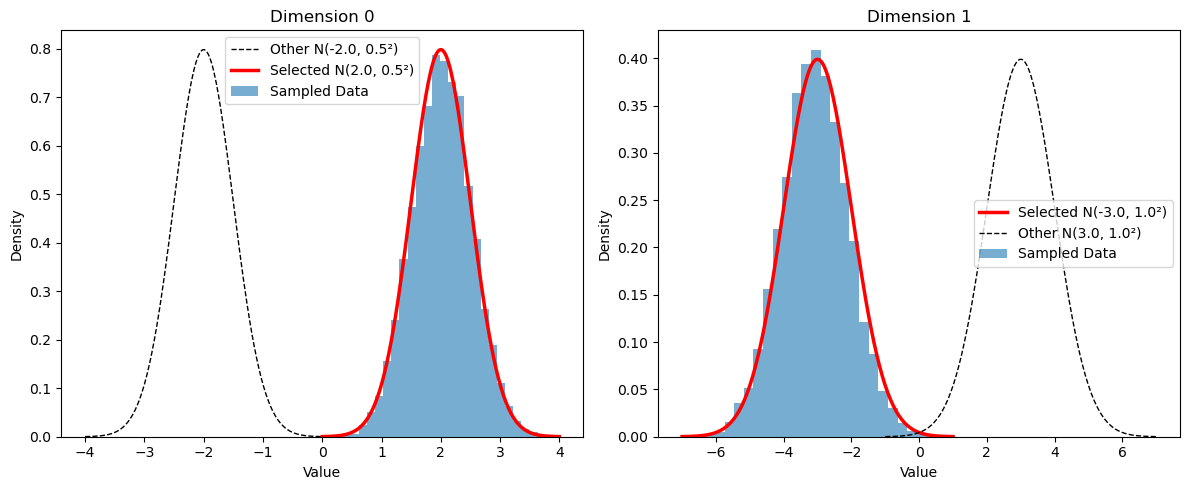

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

fig, axs = plt.subplots(1, 2, figsize=(12, 5))

for dim in range(2):
    selected_label = int(conditionals[0, dim].numpy())  # 0 or 1

    for comp in range(2):
        mean = means[dim, comp].numpy()
        std = stddevs[dim, comp].numpy()

        x_vals = np.linspace(mean - 4 * std, mean + 4 * std, 200)
        if comp == selected_label:
            axs[dim].plot(x_vals, norm.pdf(x_vals, mean, std), 'r-', lw=2.5, label=f'Selected N({mean}, {std}²)')
        else:
            axs[dim].plot(x_vals, norm.pdf(x_vals, mean, std), 'k--', lw=1.0, label=f'Other N({mean}, {std}²)')

    axs[dim].hist(samples[:, dim], bins=26, density=True, alpha=0.6, label='Sampled Data')
    axs[dim].set_title(f"Dimension {dim}")
    axs[dim].legend()
    axs[dim].set_xlabel("Value")
    axs[dim].set_ylabel("Density")

plt.tight_layout()
plt.show()
